# Challenge 01 - Sensor Fusion with Non-Gaussian Noise

Two sensors watch one maneuvering target. Neither has Gaussian noise: one is heavy-tailed
(occasional wild returns), the other is **bimodal** (multipath — with probability $p$ the reported
range is the reflected path, not the direct one). Fuse them.

The point of this challenge is not to implement a filter. It is to **state your assumptions and
justify your filter choice in terms of the noise structure and the multi-modality** — and then to
show, with a diagnostic, that you were right.

**Honest baselines** (Chapter 0
[L02](../../chapter_00_problem_formulation/lessons/L02_baselines.md)) — you must beat all three:

1. Constant-velocity extrapolation ignoring the sensors after $t=0$.
2. A single Kalman filter on sensor A only, with $R$ set to the *sample* covariance of A's errors.
3. A Kalman filter fusing both sensors with Gaussian $R$ blocks and innovation gating.

**Evaluation protocol** (Chapter 1
[L03](../../chapter_01_ts_foundations/lessons/L03_temporal_evaluation.md)):
50 independent Monte-Carlo runs with different seeds. Report **median and IQR** of position RMSE,
not the mean — heavy tails will otherwise let one lucky run decide the winner. Break the error
down by cruise vs. maneuver. Tune anything you tune on runs 0-24, and report only on runs 25-49.

**Required deliverables:** the assumption table (Part 4) and the post-mortem (Part 5).

sensor A error: median     90 m   99th pct      396 m   max       541 m
sensor B: 15% of returns are multipath (range biased +900 m)


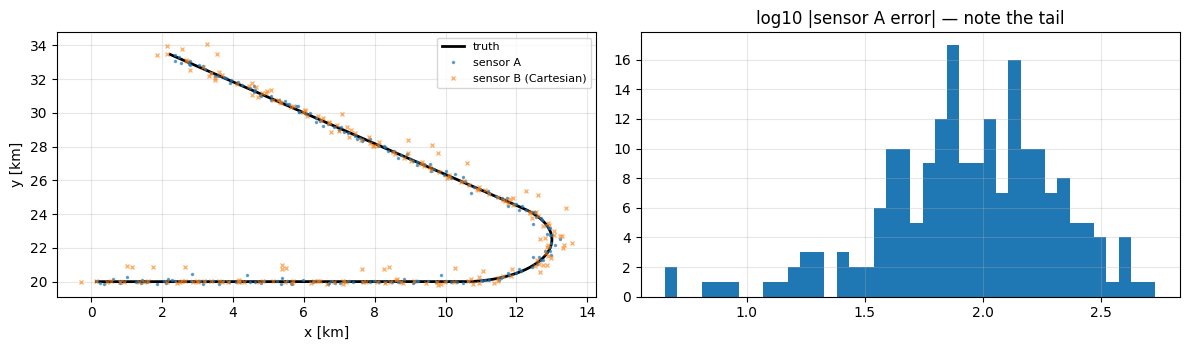

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.figsize": (11, 3.4), "axes.grid": True, "grid.alpha": 0.3})

DT, T = 1.0, 200
TURN = (70, 110)


def simulate(seed):
    """Truth + two sensors. A: heavy-tailed position. B: range/bearing with multipath bias."""
    rng = np.random.default_rng(seed)
    x = np.array([0.0, 150.0, 20000.0, 0.0])          # px, vx, py, vy
    truth = np.zeros((T, 4))
    for t in range(T):
        w = 0.06 if TURN[0] <= t < TURN[1] else 0.0
        if abs(w) < 1e-9:
            F = np.array([[1, DT, 0, 0], [0, 1, 0, 0], [0, 0, 1, DT], [0, 0, 0, 1]])
        else:
            s, c = np.sin(w * DT), np.cos(w * DT)
            F = np.array([[1, s / w, 0, -(1 - c) / w], [0, c, 0, -s],
                          [0, (1 - c) / w, 1, s / w], [0, s, 0, c]])
        x = F @ x
        truth[t] = x

    # Sensor A: Cartesian position, Student-t errors (nu=2.5) - heavy tails, no finite variance
    nu, sig = 2.5, 60.0
    zA = truth[:, [0, 2]] + sig * rng.standard_t(nu, size=(T, 2))

    # Sensor B: range + bearing from the origin, with 12% multipath (range biased by +900 m)
    r = np.hypot(truth[:, 0], truth[:, 2])
    th = np.arctan2(truth[:, 2], truth[:, 0])
    multipath = rng.random(T) < 0.12
    zB = np.c_[r + rng.normal(0, 25, T) + 900.0 * multipath,
               th + rng.normal(0, np.deg2rad(0.5), T)]
    return truth, zA, zB, multipath


truth, zA, zB, mp = simulate(0)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(truth[:, 0] / 1e3, truth[:, 2] / 1e3, "k-", lw=2, label="truth")
ax[0].plot(zA[:, 0] / 1e3, zA[:, 1] / 1e3, ".", ms=3, alpha=0.6, label="sensor A")
bx, by = zB[:, 0] * np.cos(zB[:, 1]), zB[:, 0] * np.sin(zB[:, 1])
ax[0].plot(bx / 1e3, by / 1e3, "x", ms=3, alpha=0.6, label="sensor B (Cartesian)")
ax[0].legend(fontsize=8); ax[0].set_xlabel("x [km]"); ax[0].set_ylabel("y [km]")
err_a = np.linalg.norm(zA - truth[:, [0, 2]], axis=1)
ax[1].hist(np.log10(err_a), bins=40)
ax[1].set_title("log10 |sensor A error| — note the tail")
plt.tight_layout()
print(f"sensor A error: median {np.median(err_a):6.0f} m   99th pct {np.percentile(err_a, 99):8.0f} m"
      f"   max {err_a.max():9.0f} m")
print(f"sensor B: {mp.mean():.0%} of returns are multipath (range biased +900 m)")

## Part 1 - Characterise the noise before choosing anything

Do this first, and write down what you find:

* Fit a Gaussian to sensor A's errors. What does the QQ plot say? What happens to the fitted
  $\sigma$ as you add more samples? (Hint: $\nu=2.5$ means the variance exists but barely; try
  $\nu=1.5$ and watch it not converge.)
* Plot sensor B's range residual against the truth. Is it one distribution or two?
* Which sensor is better in the median? Which is better at the 99th percentile? Does the ranking
  change with the metric — and which metric matches the decision you care about?

## Part 2 - Choose your filter, from the decision gate

Chapter 2 [L02](../lessons/L02_nonlinear_filters.md) gives the gate. Answer it explicitly in your
write-up:

1. Is the posterior unimodal and roughly Gaussian? For which sensor, and *when*?
2. Is the nonlinearity mild across your current $\pm3\sigma$? (Sensor B is polar; at 20 km a
   0.5° bearing error is 175 m of cross-range.)
3. Is the multi-modality caused by the dynamics, by the measurement model, or by association?

Candidate approaches, in rough order of effort — pick one and defend it, or compare two:

* Gaussian fusion + **innovation gating** with a $\chi^2$ threshold (cheap; what does gating do to
  your effective $P_D$, and to the bias when the *biased* mode is the one that survives the gate?).
* A **robust likelihood**: replace the Gaussian in the update with a Student-t (a variational or
  IRLS-style down-weighting of large innovations).
* A **Gaussian-mixture / multi-hypothesis** update for sensor B: two components, direct and
  multipath, with weights — exact for this noise model, and cheap.
* A **particle filter** with the true (heavy-tailed, bimodal) likelihoods. General, but check the
  caveats from the [walkthrough](../walkthroughs/lesson_maneuvering_target.ipynb): a bootstrap PF
  needs a wide enough proposal, or the truth leaves the particle cloud during the turn.
* An **IMM** on top of any of the above, if you also want the maneuver handled
  ([L03](../lessons/L03_motion_models_imm.md)).

## Part 3 - Baselines and evaluation harness

Implement the three baselines listed at the top, then your method, then run the Monte-Carlo.

In [2]:
def monte_carlo(method, seeds):
    """method(zA, zB) -> estimated (T, 2) positions. Returns per-run RMSE overall / turn / cruise."""
    rows = []
    for s in seeds:
        truth_s, zA_s, zB_s, _ = simulate(s)
        est = method(zA_s, zB_s)
        e = np.linalg.norm(est - truth_s[:, [0, 2]], axis=1)
        m = np.zeros(T, bool)
        m[TURN[0]:TURN[1]] = True
        rows.append((np.sqrt((e ** 2).mean()), np.sqrt((e[m] ** 2).mean()), np.sqrt((e[~m] ** 2).mean())))
    return np.array(rows)


def report(name, rows):
    q = np.percentile(rows, [25, 50, 75], axis=0)
    print(f"{name:<28} median {q[1, 0]:7.1f}  IQR [{q[0, 0]:6.1f}, {q[2, 0]:7.1f}]"
          f"   turn {q[1, 1]:7.1f}   cruise {q[1, 2]:7.1f}")


# baseline 0: sensor A raw (no filtering at all) - the floor
report("raw sensor A", monte_carlo(lambda zA, zB: zA, range(25, 50)))

# TODO: baseline 1 - constant-velocity extrapolation from the first two A returns
# TODO: baseline 2 - Kalman on A only, R = sample covariance of A's errors
# TODO: baseline 3 - Gaussian fusion of A and B with gating
# TODO: your method

raw sensor A                 median   151.7  IQR [ 145.7,   178.4]   turn   137.0   cruise   156.6


## Part 4 - Assumption table (required)

| Component | Assumption made | Why it is defensible here | What would break it |
| --- | --- | --- | --- |
| Motion model | | | |
| Process noise $Q$ | | | |
| Sensor A likelihood | | | |
| Sensor B likelihood | | | |
| Fusion / association | | | |
| Posterior representation | | | |

## Part 5 - Post-mortem (required)

1. **Consistency.** Report NIS for your filter (Chapter 2 [L01](../lessons/L01_kalman_filter.md)).
   Is it inside the $\chi^2$ band? If you used a robust or mixture likelihood, what is the correct
   consistency check, and why is plain NIS no longer the right one?
2. **Where the baselines fail.** Show a single run where the Gaussian-fusion baseline is dragged
   off by a multipath return. Quantify how far, and how long it takes to recover.
3. **The bias question.** Gating rejects outliers — but multipath returns are *biased*, not
   symmetric. Does your estimator inherit a bias? Estimate it. (Plot mean error along the
   range direction, not just RMSE.)
4. **Ablate the noise.** Re-run with $\nu=8$ (nearly Gaussian) and with multipath probability 0.
   Does your method still beat the Gaussian baseline? If it does not, that is the correct result
   and you should say so: robustness is not free, and it costs efficiency exactly when the
   Gaussian assumption is true.
5. **The decision.** If this fed a collision-avoidance alert at 500 m separation, which error
   statistic would you report to the customer, and why is median RMSE probably not it
   (Chapter 6 [L01](../../chapter_06_probabilistic_prediction/lessons/L01_quantiles_and_pinball.md))?